# Hypothesis Testing
## Single Proportion Test

## Jobs Training Programs

- Suppose the national unemployment rate is **30%**
- A jobs program trains 60 people; **15 are unemployed** (25%)
- The organization claims this proves the program works
- Is that difference (25% vs 30%) meaningful or just random?

## Create the Data

Now let's create some data to match our hypothetical example.

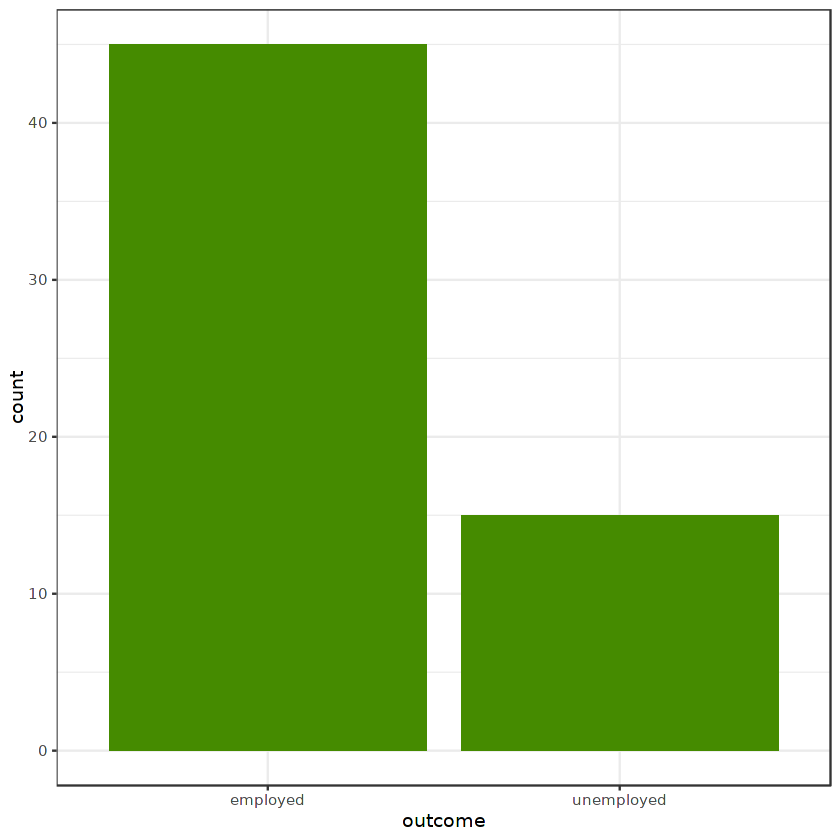

In [1]:
suppressPackageStartupMessages({
#tidyverse
library(dplyr)
library(ggplot2)

#tidymodels
library(infer)
    
})

jobs_program <- tibble(
  outcome = c(rep("unemployed", 15), rep("employed", 45))
)

jobs_program |>
  ggplot(aes(x = outcome)) +
  geom_bar(fill = "chartreuse4") + theme_bw()

In [2]:
jobs_program

outcome
<chr>
unemployed
unemployed
unemployed
unemployed
unemployed
unemployed
unemployed
unemployed
unemployed


## Question

Is it possible to assess this hypothetical organization's claim using the data and information presented thus far?

> *"Our jobs program is a **success** because only 15 of the 60 people that we trained did not have a job. Thus our 25% unemployment rate beats the country's unemployment rate of 30%."*

## Correlation vs. Causation

- **No.** We need to know more about how people were selected for the program in order to assess causality (e.g., were they randomly assigned?)
- But, we can still ask whether the unemployment rate of $\hat{p}$ = 0.25 could be due to chance.
- That's a question about the **sampling variability**.
- Now we'll use a **hypothesis test** to answer it.

## Hypothesis Testing Intuition

1. We are going to assume **"nothing is going on"**
   - In this case, the jobs program had no impact

2. We figure out what the **distribution of outcomes** might look like if nothing is going on
   - Here: if we take a sample of 60 from a population where the proportion parameter is 0.30

3. We assess **how likely** we would be to observe our data if nothing is going on
   - If very unlikely, we conclude that something is probably going on

## Stating our Hypotheses — One-Sided (Lower-Tail) Test

**This is a one-sided (lower-tail) test** — we are asking whether the program's unemployment rate is *lower* than the national rate.

**Null hypothesis ($H_0$):** "There is nothing going on."
> Unemployment rate among those in the jobs program is no different than the country average of 30%.
>
> $H_0: p = 0.30$

**Alternative hypothesis ($H_A$):** "There is something going on."
> Unemployment rate is **lower** than the country average of 30%.
>
> $H_A: p < 0.30$

**Why one-sided?** We have a directional claim: the organization says the program *reduces* unemployment. We are only checking the *lower* tail of the distribution.

## Hypothesis Test

- **Hypothesis test:** If the null hypothesis were true, is the data we have in our sample likely to have been generated by chance (due to random variability)?
- If **yes** → we do **NOT** reject the null hypothesis
- If **not very likely** → we **reject** the null hypothesis

## Hypothesis Testing Framework

1. Start with the **null hypothesis** $H_0$, representing the status quo
2. Set an **alternative hypothesis** $H_A$, representing the research question
3. Conduct a hypothesis test under the assumption that the null hypothesis is true:
   - If the test results suggest the data do **not** provide convincing evidence for $H_A$ → stick with $H_0$
   - If they **do** → reject $H_0$ in favor of $H_A$

## p-values and Critical Values

- A **p-value** is the probability of the observed or more extreme outcome given that the **null hypothesis is true**
  - *Interpretation:* If $H_0$ were true, how likely would we be to see data at least as extreme as what we observed — just by chance?
  - A **small** p-value means our data is *unlikely* under $H_0$ → evidence against $H_0$
  - A **large** p-value means our data is *plausible* under $H_0$ → no strong evidence against $H_0$
  - **Note:** A p-value is NOT the probability that $H_0$ is true!
- A **critical value** ($\alpha$) is the threshold at which we will reject the null hypothesis
- If the p-value is less than $\alpha$, we **reject** the null hypothesis
- If the p-value is greater than or equal to $\alpha$, we **fail to reject** the null hypothesis (we do NOT "accept" it!)
- A standard threshold for $\alpha$ is **0.05**

## The Null Distribution

- Since $H_0: p = 0.30$, we need to simulate a null distribution where the probability of success (unemployment) for each trial (person in program) is 0.30

- We want to know how likely we would be to get an unemployment rate of 0.25 in our sample of 60, *if the true unemployment rate were 0.30*

$$P(\hat{p} \le 0.25 \mid p = 0.30)$$

_Aside_: $\hat{p}$ is the sample proportion (statistic) and $p$ is the population proportion (parameter). <br>You need to know something about the population or 'status quo' for the null hypothesis. 

---
We to simulate the null distribution many times...

We can use the `infer` package to help with this process.

In [4]:
set.seed(77)
# simulate the distribution
null_dist <- jobs_program |>
  specify(response = outcome, success = "unemployed") |>
  hypothesize(null = "point", p = c("unemployed" = 0.30, "employed" = 0.70)) |>
  generate(reps = 3000, type = "draw") |> 
  calculate(stat = "prop")

What is being stored in *null_dist*? 

Many samples are created of $n = 60$. We told R to make the samples "unemployed" at a 30% rate. R did this for 3000 times. For each sample group, it also computed the proportions. Below we look at those proportions. The null distribution is a collections of these statistics. 

We look at the likelihood of getting any particular value within this 'status quo' simulation. 

In [ ]:
null_dist |>
  mutate(
    replicate = as.numeric(replicate),
    stat = round(stat, 3)
    ) 

Where should this distribution be centered? What should the mean be?

In [ ]:
null_dist |>
  summarize(mean = mean(stat))

The center of the null distribution should be around whatever the null statistic was that was used to simulate it. In this case, it was the around $p=0.3$.

### Visualizing the Null Distribution

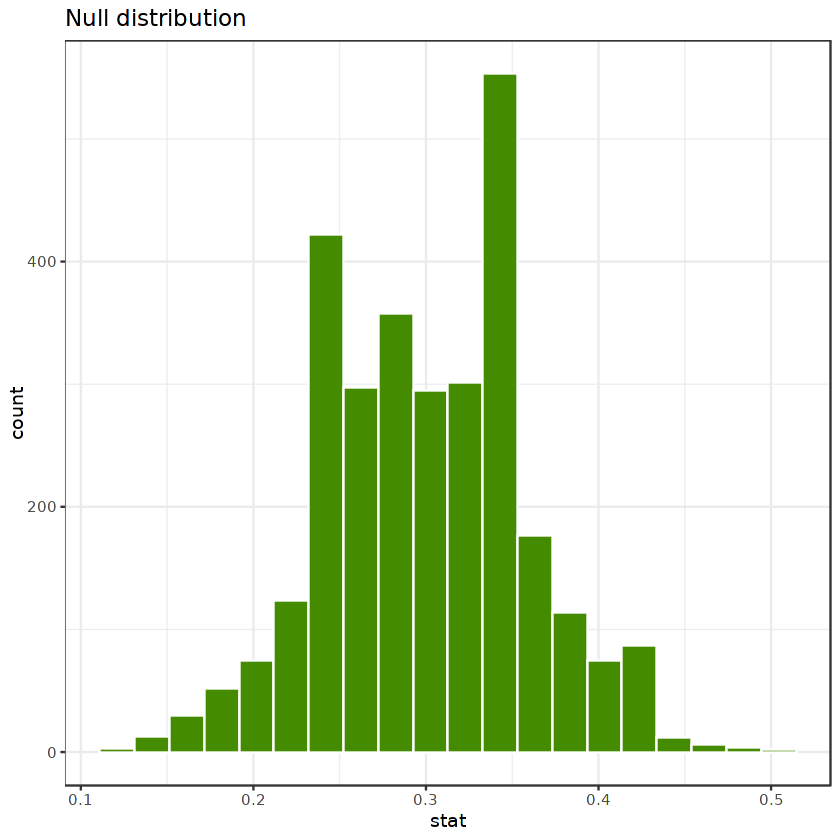

In [5]:
ggplot(data = null_dist, mapping = aes(x = stat)) +
  geom_histogram(bins = 20, fill = "chartreuse4", color = "white") +
  labs(title = "Null distribution") + theme_bw()

### Calculate the p-value

_Definition_ 

**p-value:** the proportion of simulated samples that are as extreme or more extreme than what we observed, assuming the null hypothesis is true.

We calculate to p-value to see what the chance is that something like an *alternative* hypothesis would occur in the null world. Looking at the the 3,000 possible proportions simulated in the null distribution, how many of them are proportions that are 25% or more extreme? That is, how many have unemployment that is 25% or better? 

In [6]:
null_dist |>
  filter(stat <= (15/60)) |>
  summarize(p_value = n()/nrow(null_dist))

p_value
<dbl>
0.2396667


This tells us roughly 24% of those in the null world had 25% unemployment or less. So that number is not very extreme. Let's see...

### Visualizing the p-value

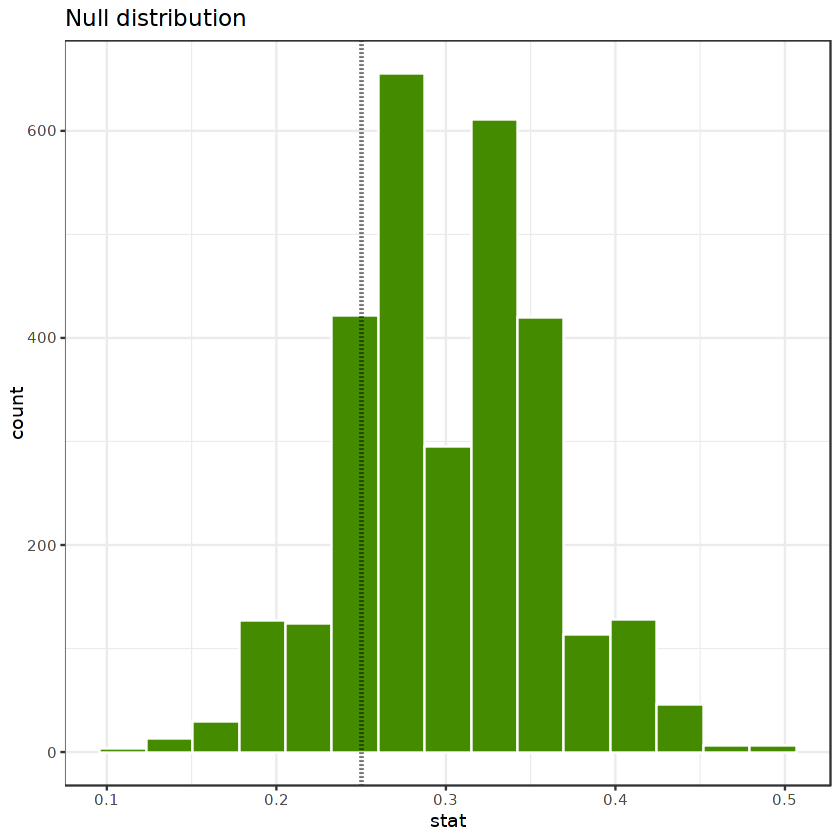

In [7]:
ggplot(data = null_dist, mapping = aes(x = stat)) +
  geom_histogram(bins = 15, fill = "chartreuse4", color = "white") +
  labs(title = "Null distribution") +     
  geom_vline(xintercept = .25, linetype="dotted", 
                color = "black", linewidth=1) + theme_bw()

Handy functions for computing p-value using `infer`

In [9]:
library(infer)

# calculate the p-value from null distribution
p_value <- null_dist |>
  get_p_value(obs_stat = 15/60, direction = "less")

p_value

p_value
<dbl>
0.2396667


Visualizing the p-value using `infer`

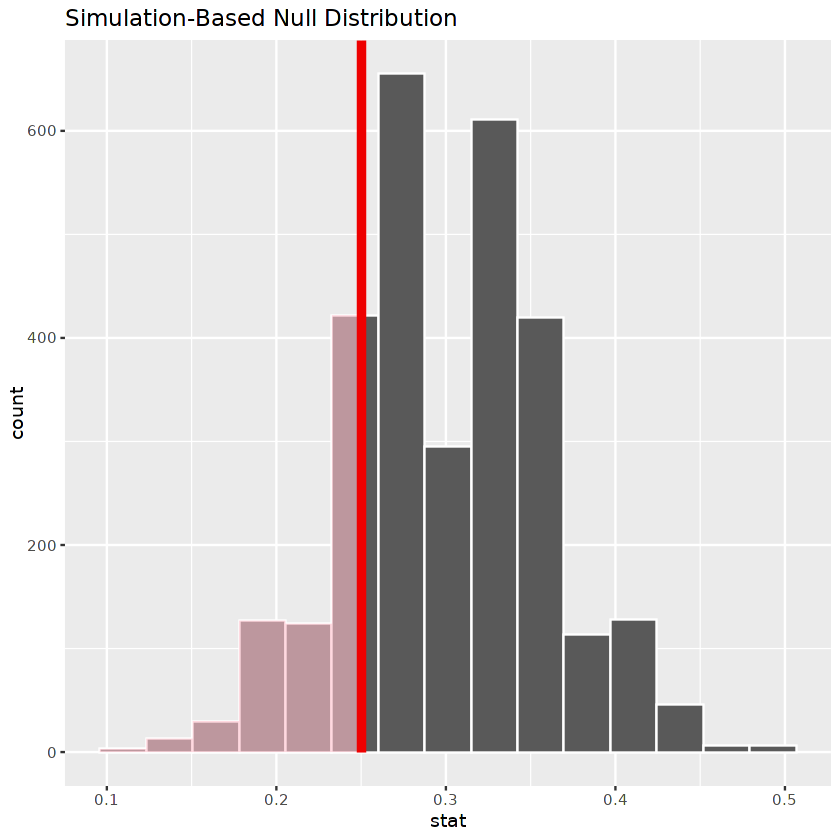

In [10]:
visualize(null_dist) +
  shade_p_value(obs_stat = 15/60, direction = "less")

## "Significance" Level

- Conventionally, people use a p-value of **0.05** as a cutoff ("significance level") for determining statistical significance
  - i.e., whether the null hypothesis should be rejected
  - i.e., whether the data is very unlikely to have been generated due to chance
- **Why 0.05?** It is purely a convention — a rule of thumb adopted by statisticians over time. There is nothing mathematically special about 0.05.
  - It means we are willing to accept a 5% chance of rejecting the null hypothesis when it is actually true (a "false positive", also called a **Type I error**)
  - In some fields (e.g., physics), researchers use much stricter thresholds like 0.001
  - In practice, always think about the *context* — how costly would it be to make a wrong decision?
- Always remember that this is a **convention**
  - *p = 0.049* is under the cutoff, while *p = 0.051* is not — are these really different?
- When people report "statistically significant" results, they mean the p-value is less than 0.05

## Our Hypothetical Study

- **Our finding:** if the true unemployment rate were 30% and we draw samples of 60, about 23% of the time we will get an unemployment rate lower than the one among program participants — simply due to random chance.
- **What should we conclude?**

## Conclusion

We do **NOT** reject the null hypothesis: the unemployment rate in the sample could likely have been **due to chance**.

## Try it out!

- What if the unemployment rate for the program was only **15%**?
  - Would you reject the null hypothesis in this case?
  - Demonstrate by calculating the p-value
- Try changing the true unemployment rate in the null distribution to **0.50 (50%)**
  - Simulate the null distribution
  - Would you reject the null hypothesis if the observed unemployment rate was 23% in this case?

In [ ]:
p_value <- null_dist |>
  get_p_value(obs_stat = 9/60, direction = "less")

p_value

In [ ]:
visualize(null_dist) +
  shade_p_value(obs_stat = 9/60, direction = "less")

In [ ]:
null_dist <- jobs_program |>
  specify(response = outcome, success = "unemployed") |>
  hypothesize(null = "point", p = c("unemployed" = 0.50, "employed" = 0.50)) |>
  generate(reps = 20000, type = "draw") |> 
  calculate(stat = "prop")

In [ ]:
p_value <- null_dist |>
  get_p_value(obs_stat = .23, direction = "less")

p_value

In [ ]:
visualize(null_dist) +
  shade_p_value(obs_stat = .23, direction = "less")





The previous example is an example of of **One-Sided (Lower-Tail) Test**. 

We could frame it differently and do the test on the other side.

---
## Example 2: One-Sided (Upper-Tail) Test

Now suppose we flip the question: **Does the jobs program lead to a higher employment rate?**

- National *employment* rate: **70%** (= 1 − 0.30)
- Among the 60 program participants, **45 are employed** (75%)
- We want to test: is the employment rate **higher** than the national rate?

This is still the same data — we are just choosing `success = "employed"` instead of `"unemployed"` to change which tail we look at.

### Stating the Hypotheses — One-Sided (Upper-Tail) Test

**Null hypothesis ($H_0$):** The program does not improve employment.
> Employment rate is equal to the national rate of 70%.
>
> $H_0: p = 0.70$

**Alternative hypothesis ($H_A$):** The program improves employment.
> Employment rate is **higher** than 70%.
>
> $H_A: p > 0.70$

**Why upper-tail?** We now define `success = "employed"` and our observed $\hat{p} = 45/60 = 0.75 > 0.70$, so we look at the **right/upper tail**.

In [11]:
# One-Sided Upper-Tail Test: is employment rate HIGHER than 70%?
# Note: success is now "employed" — we flipped which category we track

set.seed(77)
null_dist <- jobs_program |>
  specify(response = outcome, success = "employed") |>
  hypothesize(null = "point", p = c("employed" = 0.70, "unemployed" = 0.30)) |>
  generate(reps = 3000, type = "draw") |>
  calculate(stat = "prop")

In [13]:
# Calculate the p-value (upper/right tail: direction = "greater")
p_value_upper <- null_dist |>
  get_p_value(obs_stat = 45/60, direction = "greater")

p_value_upper

p_value
<dbl>
0.2396667


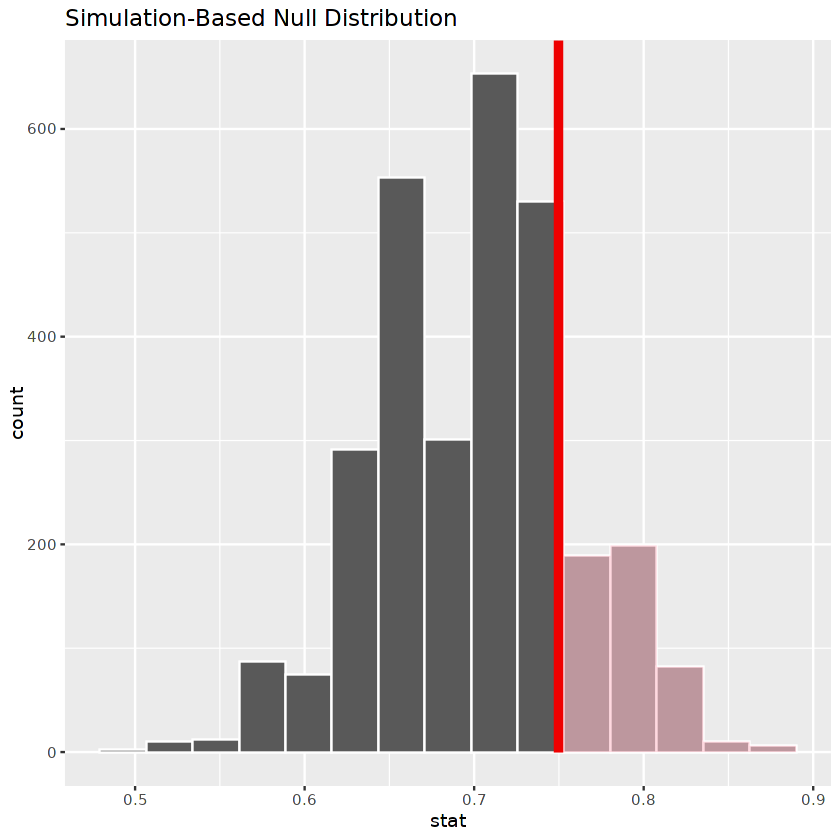

In [15]:
# Visualize the p-value (shaded region is the upper/right tail)
visualize(null_dist) +
  shade_p_value(obs_stat = 45/60, direction = "greater")

### Conclusion — Upper-Tail Test

Compare the p-value to $\alpha = 0.05$:

- If **p-value < 0.05** → we **reject** $H_0$; there is statistically significant evidence that the employment rate is higher than 70%.
- If **p-value ≥ 0.05** → we **fail to reject** $H_0$; the data is consistent with the program having no effect.

> **Key observation:** This is the *same data* as the lower-tail test, just with `success = "employed"` and `direction = "greater"`. The p-value will be the same (approximately ~0.23-0.25), and we again fail to reject $H_0$.

> **Important:** Always decide whether your test is one-sided or two-sided *before* looking at the data, based on your research question.

---
## Example 3: Two-Sided Test — Is This Coin Fair?

### When do we use a two-sided test?

Use a **two-sided test** when you have no prior directional expectation — you simply want to know whether there is *any* difference from the null value, in *either* direction.

**Scenario:** You flip a coin 100 times and get **60 heads**. Is the coin fair?

- A fair coin should land heads 50% of the time.
- 60 heads out of 100 flips is higher than expected — but is it *significantly* higher, or just random chance?
- Importantly, we don't have a directional expectation: a biased coin could favor heads *or* tails.

### Stating the Hypotheses — Two-Sided Test

**Null hypothesis ($H_0$):** The coin is fair.
> $H_0: p = 0.50$

**Alternative hypothesis ($H_A$):** The coin is biased (in either direction).
> $H_A: p \neq 0.50$

**Why two-sided?** A biased coin could come up heads *too often* or *too rarely* — we care about either possibility, so we check **both tails**.

> **Note on p-value:** For a two-sided test, the p-value counts extremes on *both sides* of the null. In `infer`, use `direction = "two-sided"`.

In [16]:
# Create the coin flip data: 60 heads, 40 tails out of 100 flips
coin_flips <- tibble(
  result = c(rep("heads", 60), rep("tails", 40))
)

In [18]:
# Simulate the null distribution (H0: p = 0.50)
null_dist_coin <- coin_flips |>
  specify(response = result, success = "heads") |>
  hypothesize(null = "point", p = c("heads" = 0.50, "tails" = 0.50)) |>
  generate(reps = 3000, type = "draw") |>
  calculate(stat = "prop")

In [19]:
# Calculate the p-value — two-sided (checks BOTH tails)
p_value_coin <- null_dist_coin |>
  get_p_value(obs_stat = 60/100, direction = "two-sided")

p_value_coin

p_value
<dbl>
0.054


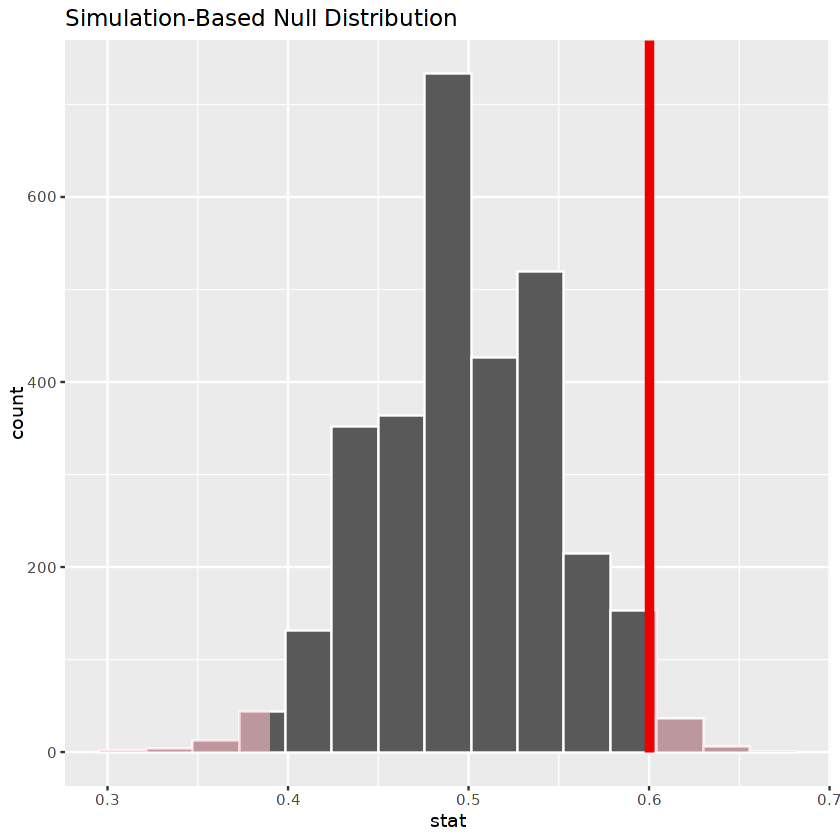

In [20]:
# Visualize: both tails are shaded
# Notice the shading appears on BOTH sides of the distribution
visualize(null_dist_coin) +
  shade_p_value(obs_stat = 60/100, direction = "two-sided")

### Conclusion — Two-Sided Test

Compare the p-value to $\alpha = 0.05$:

- If **p-value < 0.05** → **reject** $H_0$; there is statistically significant evidence that the coin is biased.
- If **p-value ≥ 0.05** → **fail to reject** $H_0$; 60 heads out of 100 is plausible for a fair coin just by random chance.

### One-Sided vs. Two-Sided: Summary

| | One-Sided (Lower) | One-Sided (Upper) | Two-Sided |
|---|---|---|---|
| $H_A$ | $p < p_0$ | $p > p_0$ | $p \neq p_0$ |
| `direction =` | `"less"` | `"greater"` | `"two-sided"` |
| Shaded tail | Left | Right | Both |
| Use when | Expecting *lower* | Expecting *higher* | No directional expectation |

> **Practical advice:** When in doubt, use a two-sided test. It is more conservative (harder to reject $H_0$), and the two-sided p-value is roughly twice the one-sided p-value for the same data.